# Testing EI-RNN Initialization for CTDS

Compare EM convergence and parameter recovery between:
1. **Random init** — default `CTDS` initialization
2. **EI-RNN init** — data-driven initialization via constrained regression + NMF

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation.ctds import CTDS
from pillow_lab_rotation.simulate import CTDSSim, generate_pulsatile_inputs

plt.style.use('../Js.mplstyle')

## Simulate ground-truth CTDS data

In [21]:
Ne, Ni = 10, 10
De, Di = 5, 5
udim = 3
n_trials = 100
T = 100

np.random.seed(0)
sim = CTDSSim(De, Di, Ne, Ni, udim=udim)
sim.create_params()
A_true, C_true, Q_true, Q0_true, mu0_true, R_true, B_true = sim.get_params()

U_all = generate_pulsatile_inputs(n_trials, T, udim)
X_all, Y_all = sim.simulate(T, n_trials, inputs=U_all)
print(f"Observations shape: {Y_all.shape}")
print(f"Inputs shape: {U_all.shape}")
print(f"A spectral radius: {np.max(np.abs(np.linalg.eigvals(A_true))):.3f}")

Observations shape: (100, 100, 20, 1)
Inputs shape: (100, 100, 3, 1)
A spectral radius: 0.571


## Fit with random initialization

In [22]:
np.random.seed(0)
ctds_random = CTDS(De, Di, Ne, Ni, udim=udim)
ctds_random.init_params()  # random init (no observations)
ctds_random.fit(Y_all, inputs=U_all, verbose=True, criterion=1e-6)

Iteration 0: LL = -122.840767
Iteration 1: LL = -42.891484
Iteration 2: LL = -41.556334
Iteration 3: LL = -40.946233
Iteration 4: LL = -40.581760
Iteration 5: LL = -40.333296
Iteration 6: LL = -40.161144
Iteration 7: LL = -40.043074
Iteration 8: LL = -39.962138
Iteration 9: LL = -39.905940
Iteration 10: LL = -39.865979
Iteration 11: LL = -39.836793
Iteration 12: LL = -39.814914
Iteration 13: LL = -39.798163
Iteration 14: LL = -39.785132
Iteration 15: LL = -39.774879
Iteration 16: LL = -39.766742
Iteration 17: LL = -39.760236
Iteration 18: LL = -39.754995
Iteration 19: LL = -39.750737
Iteration 20: LL = -39.747245
Iteration 21: LL = -39.744349
Iteration 22: LL = -39.741918
Iteration 23: LL = -39.739852
Iteration 24: LL = -39.738074
Iteration 25: LL = -39.736525
Iteration 26: LL = -39.735158
Iteration 27: LL = -39.733939
Iteration 28: LL = -39.732842
Iteration 29: LL = -39.731844
Iteration 30: LL = -39.730929
Iteration 31: LL = -39.730085
Iteration 32: LL = -39.729301
Iteration 33: LL = 

## Fit with EI-RNN initialization

In [27]:
np.random.seed(1)
ctds_eirnn = CTDS(De, Di, Ne, Ni, udim=udim)
ctds_eirnn.init_params(observations=Y_all, start_seed=0)  # EI-RNN init
ctds_eirnn.fit(Y_all, inputs=U_all, verbose=True, criterion=1e-6)

/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to im

Iteration 0: LL = -45.709223
Iteration 1: LL = -40.856958
Iteration 2: LL = -40.551235
Iteration 3: LL = -40.440002
Iteration 4: LL = -40.369625
Iteration 5: LL = -40.312668
Iteration 6: LL = -40.262186
Iteration 7: LL = -40.214985
Iteration 8: LL = -40.169868
Iteration 9: LL = -40.126387
Iteration 10: LL = -40.084360


KeyboardInterrupt: 

## Compare log-likelihood convergence

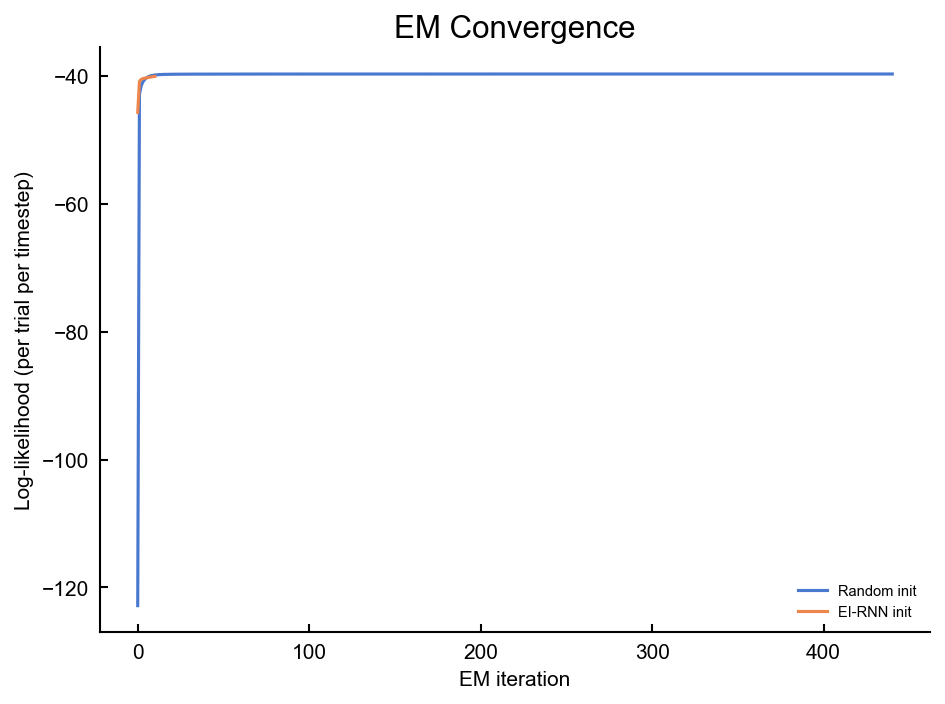

In [28]:
fig, ax = plt.subplots()
ax.plot(ctds_random.ll_history, label='Random init')
ax.plot(ctds_eirnn.ll_history, label='EI-RNN init')
ax.set_xlabel('EM iteration')
ax.set_ylabel('Log-likelihood (per trial per timestep)')
ax.legend()
ax.set_title('EM Convergence')
# ax.set_xscale('log')
# ax.set_yscale('log')
fig.tight_layout()

## Parameter recovery

Since the latent space is only identifiable up to an invertible linear transform, we align recovered parameters to ground truth via $H = (C'^T C')^{-1} C'^T C_{\text{true}}$.

In [29]:
def align_params(ctds_fit):
    """Align recovered params to ground truth via C-based linear transform."""
    C_fit = ctds_fit.C
    H = np.linalg.inv(C_fit.T @ C_fit) @ C_fit.T @ C_true
    H_inv = np.linalg.inv(H)
    A_aligned = H_inv @ ctds_fit.A @ H
    C_aligned = C_fit @ H
    Q_aligned = H_inv @ ctds_fit.Q @ H_inv.T
    B_aligned = H_inv @ ctds_fit.B
    return A_aligned, C_aligned, Q_aligned, ctds_fit.R, B_aligned

def param_mses(ctds_fit):
    A_al, C_al, Q_al, R_fit, B_al = align_params(ctds_fit)
    return {
        'A': np.mean((A_al - A_true)**2),
        'C': np.mean((C_al - C_true)**2),
        'Q': np.mean((Q_al - Q_true)**2),
        'R': np.mean((R_fit - R_true)**2),
        'B': np.mean((B_al - B_true)**2),
    }

mse_random = param_mses(ctds_random)
mse_eirnn = param_mses(ctds_eirnn)

print(f"{'Param':<6} {'Random init':>14} {'EI-RNN init':>14}")
print("-" * 36)
for key in mse_random:
    print(f"{key:<6} {mse_random[key]:>14.6f} {mse_eirnn[key]:>14.6f}")

Param     Random init    EI-RNN init
------------------------------------
A            0.000175       0.003706
C            0.000002       0.000248
Q            0.013265       1.666742
R            0.000023       0.018099
B            0.048912       0.055941


## Visual comparison of recovered matrices

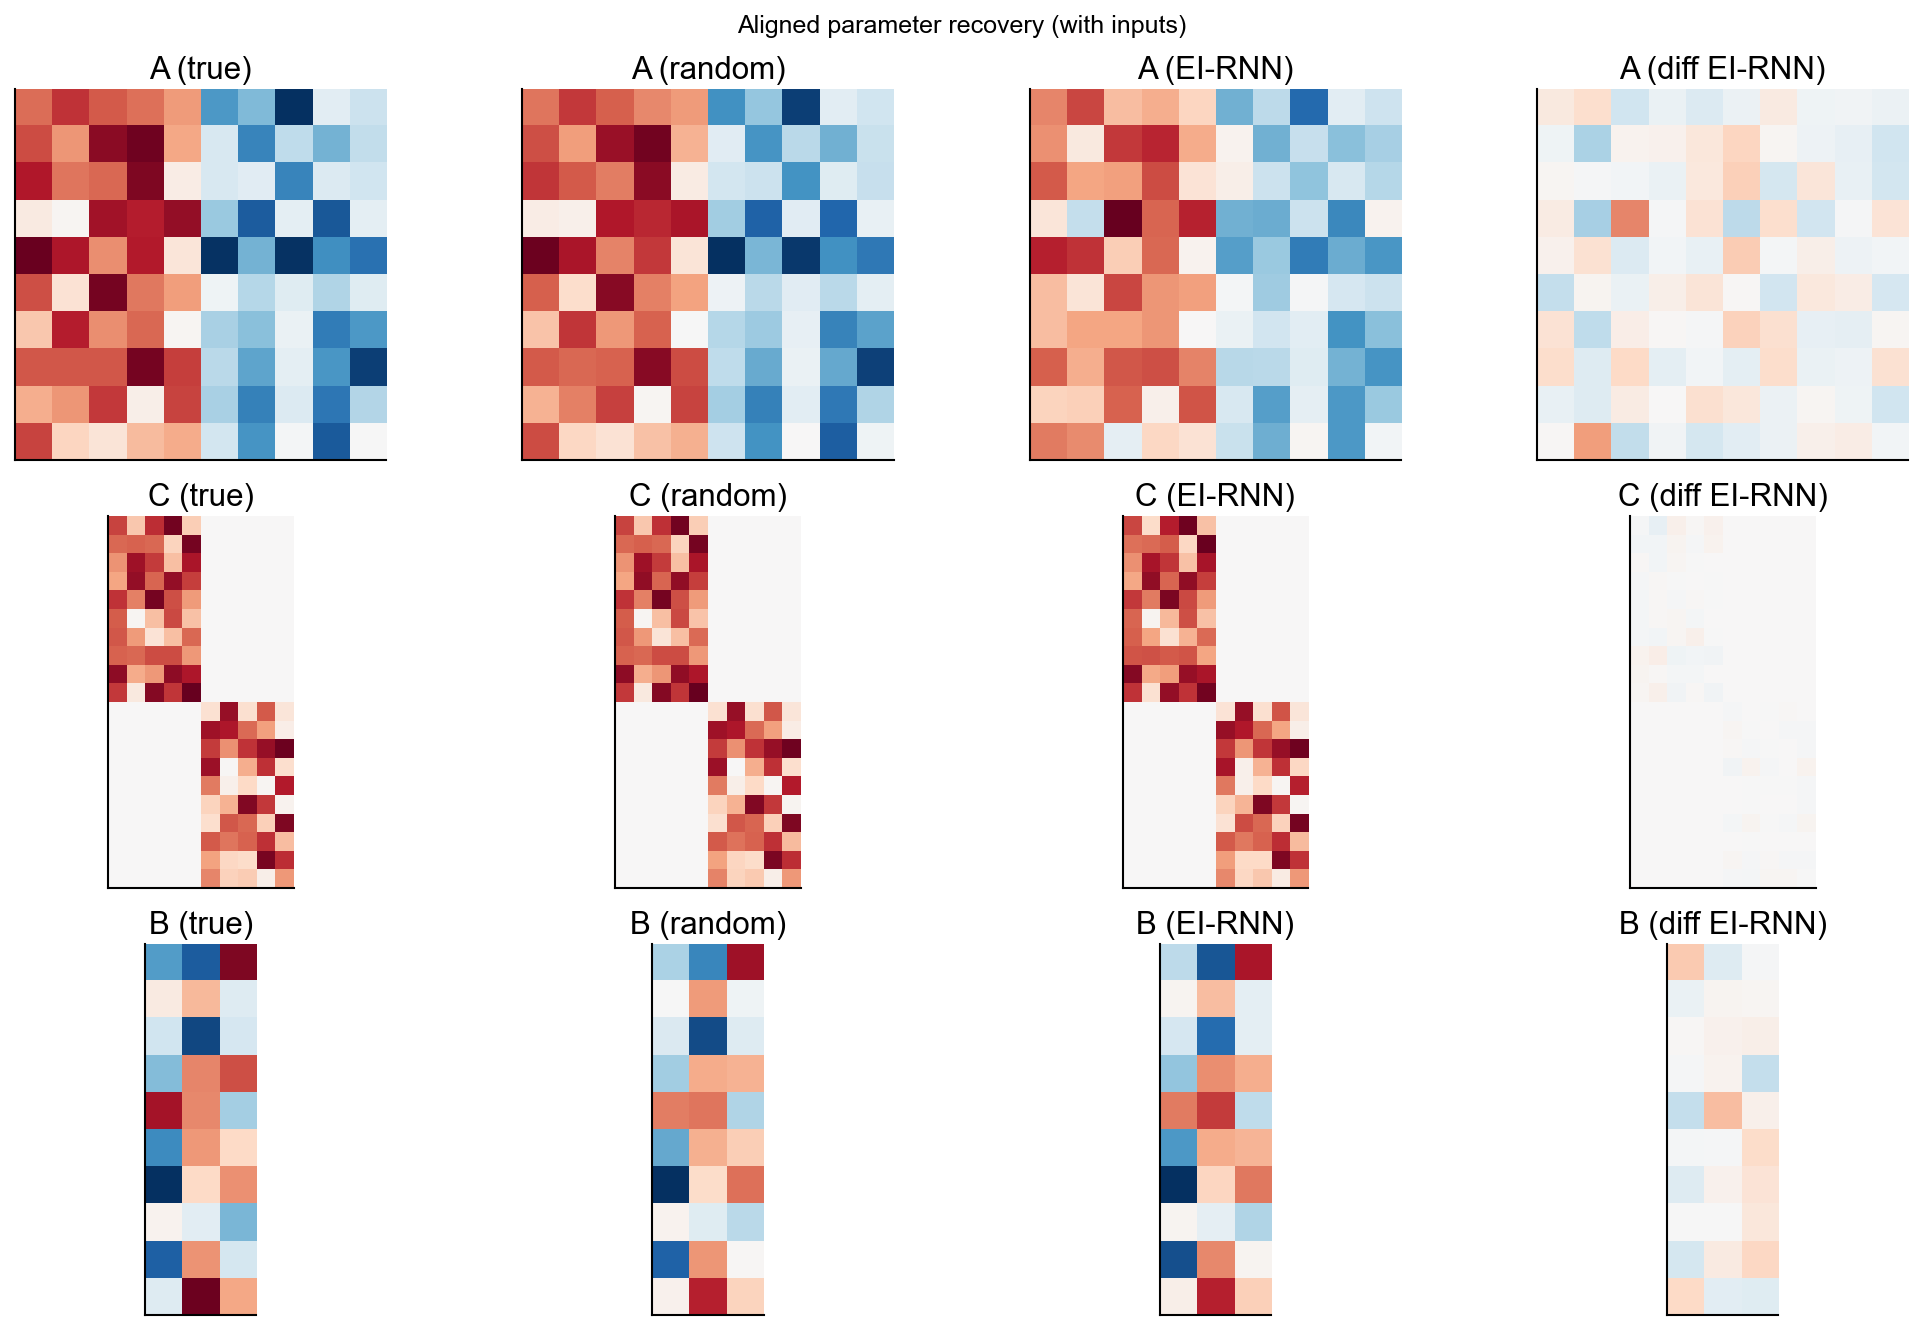

In [30]:
fig, axes = plt.subplots(3, 4, figsize=(14, 9))

A_rand, C_rand, Q_rand, R_rand, B_rand = align_params(ctds_random)
A_ei, C_ei, Q_ei, R_ei, B_ei = align_params(ctds_eirnn)

rows = [
    ('A', A_true, A_rand, A_ei),
    ('C', C_true, C_rand, C_ei),
    ('B', B_true, B_rand, B_ei),
]

for row_axes, (name, true, rand, ei) in zip(axes, rows):
    titles = [f'{name} (true)', f'{name} (random)', f'{name} (EI-RNN)', f'{name} (diff EI-RNN)']
    mats = [true, rand, ei, ei - true]
    for ax, title, mat in zip(row_axes, titles, mats):
        vmax = max(np.abs(true).max(), np.abs(mat).max())
        ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('Aligned parameter recovery (with inputs)')
fig.tight_layout()